# First model: Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. 

In [63]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from data import utils

## Load Data

In [335]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)

In [336]:
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')
eng_non_spectral_df = eng_non_spectral_df[eng_non_spectral_df["in_season"]  == 1]


roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

### Extracting Anomaly Data

In [337]:
def get_anomaly_df(df):
    mask = df["Timestamp"].dt.year.isin([2018, 2019, 2024])
    return df[~mask].copy(), df[mask].copy()

In [338]:
norm_ns_df, anom_ns_df = get_anomaly_df(non_spectral_df)
norm_s_df, anom_s_df = get_anomaly_df(grouped_spectral_df)

norm_eng_ns_df, anom_eng_ns_df = get_anomaly_df(eng_non_spectral_df)
norm_roll_lag_df, anom_roll_lag_df = get_anomaly_df(roll_lag_df)

## Feature Selection

In [339]:
eng_features = [
    'Timestamp',
    #'in_season', 
    'cumulative_GDD', 
    #'Growth_Stage',
    'root_weighted_soil_moisture', 
    'VW_PC1', 
    'VW_PC2', 
    'Shallow_mean',
    'ST_PC1'
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation'
]


X_part1 = norm_eng_ns_df[eng_features]
X_part2 = norm_ns_df[non_spectral_features]

X_non_spectral_norm = pd.merge(X_part2, X_part1, on="Timestamp")
X_norm = utils.merge_with_master(X_non_spectral_norm, norm_s_df[["Timestamp", "NDVI_mean"]])
X_norm.head()
#X_non_spectral_train = X_non_spectral_train.drop("Timestamp", axis=1)

,Timestamp,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,VW_PC2,Shallow_mean,ST_PC1,NDVI_mean
0,2020-01-02,294.688144,288.120487,302.366209,2.902789e+07,0.458307,680.527919,0.318876,-0.111900,-1.563993,295.221049,2.056825,0.510191
1,2020-01-17,294.719824,286.586907,302.321046,3.214787e+07,0.000000,841.540970,0.289289,-1.248978,-0.888990,296.196565,2.430324,0.574295
2,2020-01-27,292.365754,286.446071,299.538116,2.793437e+07,0.000000,943.226676,0.284739,-1.438202,-0.879297,295.733822,2.280756,0.625572
3,2020-02-01,295.852130,287.679280,303.723830,2.882288e+07,2.096582,1001.658925,0.272085,-1.296044,-1.017509,296.576350,2.594508,0.608228
4,2020-02-16,293.377812,284.550084,300.881040,3.035863e+07,0.000000,1145.351872,0.290436,-0.897945,-1.145369,295.114424,2.045526,0.649440


## Training Model

In [340]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm.drop("Timestamp", axis=1))
X_norm_df = pd.DataFrame(data=X_scaled, columns=X_norm.columns.drop("Timestamp"))
X_norm_df.head()
X_norm_df.shape

(113, 12)

In [341]:
X_train, X_test = train_test_split(X_norm_df, train_size=0.8, shuffle=False)

In [342]:
bics = []
components = range(1, 12)
min_bic = np.inf
min_bic_k = 0

for k in components:
    gmm = GaussianMixture(n_components=k, covariance_type='diag' )
    gmm.fit(X_train)
    bic = gmm.bic(X_train)
    bics.append(bic)
    if bic < min_bic:
        min_bic = bic
        min_bic_k = k

Minimum BIC: 1591.4630510093966 with 11 comp


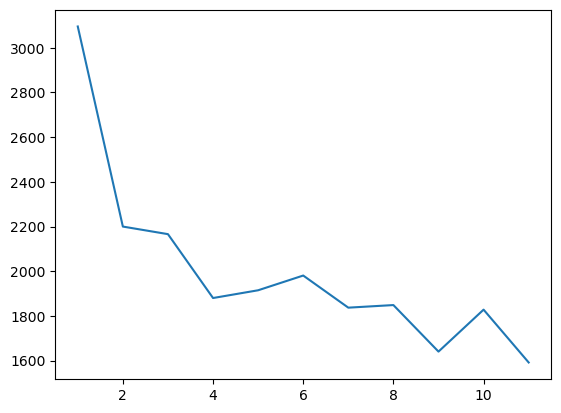

In [343]:
plt.plot(components, bics)
print(f"Minimum BIC: {min_bic} with {min_bic_k} comp")

In [345]:
gmm = GaussianMixture(n_components=4, covariance_type='diag' )
gmm.fit(X_train)

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [347]:
test_scores = gmm.score_samples( X_test)
test_scores

array([-14.22206609, -27.48282824, -20.70973392, -10.0587546 ,
       -10.36630538,  -7.68790343, -15.05515861, -18.16148677,
        -8.04665344, -17.26695426, -17.63630989, -22.60653508,
       -19.71979805, -14.28298769, -12.47720656, -11.08105664,
        -9.26806312,  -8.71842841, -11.04635649,  -9.17002894,
       -15.05602193, -13.41261078, -12.59794332])

# Anomalous Years

In [348]:
eng_features = [
    'Timestamp',
    #'in_season', 
    'cumulative_GDD', 
    #'Growth_Stage',
    'root_weighted_soil_moisture', 
    'VW_PC1', 
    'VW_PC2', 
    'Shallow_mean',
    'ST_PC1'
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation'
]


X_part1 = anom_eng_ns_df[eng_features]
X_part2 = anom_ns_df[non_spectral_features]
X_non_spectral_anom = pd.merge(X_part2, X_part1, on="Timestamp")
X_anom = utils.merge_with_master(X_non_spectral_anom, anom_s_df[["Timestamp", "NDVI_mean"]])
X_anom.head()
#X_non_spectral_train = X_non_spectral_train.drop("Timestamp", axis=1)

,Timestamp,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,VW_PC2,Shallow_mean,ST_PC1,NDVI_mean
0,2018-01-07,296.411982,288.101550,305.198672,3.187154e+07,0.000000,68.571978,0.299292,-1.183583,-0.587793,296.002958,2.313807,0.454175
1,2018-03-03,293.174303,284.739623,300.874879,2.653625e+07,5.928807,590.519890,0.281281,-1.590467,-0.552564,295.126973,2.016460,0.629801
2,2018-06-01,281.743066,275.021431,288.422674,1.504906e+07,0.000000,1008.761014,0.323971,-0.074496,-0.899455,284.986435,-1.856966,0.330054
3,2018-06-06,280.752142,274.098569,288.798194,1.452415e+07,0.000000,1008.820208,0.316398,-0.453142,-0.632810,283.505104,-2.422938,0.289118
4,2018-06-11,281.838309,276.769477,289.060574,1.396338e+07,0.000000,1008.827306,0.310607,-0.730843,-0.459625,283.815239,-2.336751,0.264834


In [349]:
X_scaled = scaler.fit_transform(X_anom.drop("Timestamp", axis=1))
X_anom_df = pd.DataFrame(X_scaled, columns=X_anom.columns.drop("Timestamp"))

In [350]:
anomaly_scores = gmm.score_samples( X_anom_df)
anomaly_scores

array([ -7.08864545, -20.28496088, -18.83878062, -19.56138492,
       -17.22456502, -36.10594882, -10.34506528,  -7.47336165,
       -14.71970154,  -7.29367487, -11.08588516, -11.35741015,
       -13.15307997, -19.0808617 , -11.715728  ,  -9.57002688,
        -8.25533579,  -5.85199389,  -6.04061807,  -4.91552718,
        -6.19006373,  -6.69358983,  -5.93353631,  -9.5819744 ,
       -10.44637285, -50.2373545 ,  -9.67360782,  -8.17358141,
       -15.54279386, -14.27159157, -13.98889316,  -9.61356024,
       -11.42356525,  -9.03635966,  -9.02485177,  -7.29448559,
        -7.84205461,  -9.98825588,  -9.82330081, -19.19475793,
       -14.98263945, -12.0257882 ,  -8.83391555,  -7.88986144,
        -9.22165404,  -7.51933048,  -7.06706468,  -5.31638166,
        -5.79060839, -12.44891962,  -9.03684196,  -8.73481693,
       -40.14010715,  -8.40852358, -12.5306884 , -19.8004696 ])

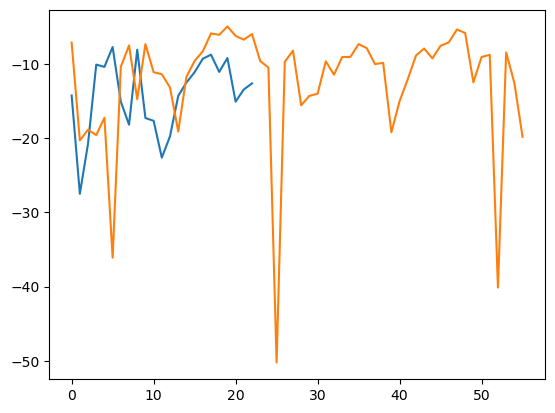

In [351]:
plt.plot(test_scores)
plt.plot(anomaly_scores)